## Librerias

In [2]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [4]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [5]:
# Cuantos partidos se jugaron?
# Completar
partidos = mundial["match_no"].sum()
partidos


np.int64(2080)

In [6]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar
mundial.info()
mundial.describe()
mundial.columns
mundial.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   match_no                         64 non-null     int64  
 1   day_of_week                      64 non-null     object 
 2   date                             64 non-null     object 
 3   hour                             64 non-null     object 
 4   venue                            64 non-null     object 
 5   referee                          64 non-null     object 
 6   group                            64 non-null     object 
 7   1                                64 non-null     object 
 8   2                                64 non-null     object 
 9   attendance                       64 non-null     int64  
 10  1_xg                             64 non-null     float64
 11  2_xg                             64 non-null     float64
 12  1_poss                  

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361


## Analisis

### Primera Parte

In [7]:
# Cuantas selecciones participaron?
# Completar
selecciones = pd.concat([mundial['1'], mundial['2']]).unique().size
selecciones

32

In [8]:
# Cuantas fases tiene el mundial?
# Completar

fases = mundial['group'].unique()
fases_totales = len(fases)
fases = fases_totales
fases

13

In [9]:
# Cual fue la "attendance" promedio por partido?
# Completar
promedio = mundial['attendance'].mean()
promedio

np.float64(53191.4375)

In [17]:
# Cual fue el partido con mas diferencia de goles?
# Completar
diferenciaGoles = (mundial['1_goals'] - mundial['2_goals']).abs()
mundial['diferenciaGoles'] = diferenciaGoles
max_diferencia = diferenciaGoles.idxmax()
partido_max_diferencia = mundial.loc[max_diferencia]

print("Partido con la mayor diferencia de goles:")
print(partido_max_diferencia[['1', '2', 'diferenciaGoles']])

Partido con la mayor diferencia de goles:
1                       SPAIN
2                  COSTA RICA
diferenciaGoles             7
Name: 10, dtype: object


In [18]:
# Cual es la selección que mas penales metió?
# Completar

penales1 = mundial.groupby('1')['1_panelties_scored'].sum()
penales2 = mundial.groupby('2')['2_panelties_scored'].sum()
penales = pd.concat([penales1, penales2]).groupby(level=0).sum()
penales.idxmax()

'ARGENTINA'

In [20]:
# Cual es la selección que mas penales le hicieron?
# Completar
penales1 = mundial.groupby('1')['2_panelties_scored'].sum()
penales2 = mundial.groupby('2')['1_panelties_scored'].sum()
penales = pd.concat([penales1, penales2]).groupby(level=0).sum()
penales.idxmax()

'FRANCE'

### Segunda Parte

In [21]:
equipo : str = "ARGENTINA"

In [22]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

Local = mundial['1'] == equipo
partidosLocal = mundial[Local]
partidosLocal

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied,diferenciaGoles
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,0,4,14,0,0,65,80,163,361,1
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,4,5,0,0,63,79,220,327,2
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,5,14,1,0,67,73,240,453,1
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,0,12,10,0,0,85,63,321,260,3
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,2,11,21,0,0,87,104,280,409,0


In [23]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

Visitante = mundial['2'] == equipo
partidosVisitante = mundial[Visitante]
partidosVisitante

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied,diferenciaGoles
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,25,4,0,0,67,48,438,141,2
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,1,15,5,0,0,91,79,401,323,0


In [25]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar

partidosArg = mundial[(mundial['1'] == equipo) | (mundial['2'] == equipo)]
partidosArg

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied,diferenciaGoles
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,0,4,14,0,0,65,80,163,361,1
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,4,5,0,0,63,79,220,327,2
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,25,4,0,0,67,48,438,141,2
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,5,14,1,0,67,73,240,453,1
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,1,15,5,0,0,91,79,401,323,0
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,0,12,10,0,0,85,63,321,260,3
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,2,11,21,0,0,87,104,280,409,0


In [27]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles = partidosLocal['1_goals'].sum() + partidosVisitante['2_goals'].sum()
goles

np.int64(15)

In [28]:
# Cuantos goles hizo el equipo en promedio
# Completar

partidos = partidosLocal.shape[0] + partidosVisitante.shape[0]
promedio = goles / partidos
promedio

np.float64(2.142857142857143)

In [29]:
ganados : int = (partidosLocal['1_goals'] > partidosLocal['2_goals']).sum() + \
               (partidosVisitante['2_goals'] > partidosVisitante['1_goals']).sum()
ganados

np.int64(4)

/tmp/ipykernel_35724/481292754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  partidosArg['equipo_goals'] = np.where(partidosArg['1'] == equipo, partidosArg['1_goals'], partidosArg['2_goals'])
/tmp/ipykernel_35724/481292754.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  partidosArg['oponente'] = np.where(partidosArg['1'] == equipo, partidosArg['2'], partidosArg['1'])


Text(0.5, 1.0, 'Goles de ARGENTINA por Partido contra cada Oponente')

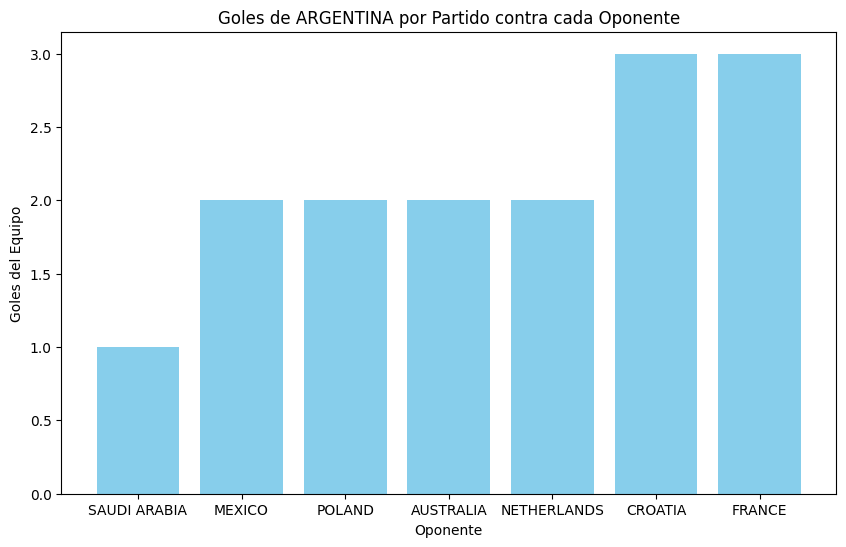

In [35]:
import numpy as np
# Graficar los goles hechos por el equipo en cada partido
# Determinar los goles del equipo en cada partido
partidosArg['equipo_goals'] = np.where(partidosArg['1'] == equipo, partidosArg['1_goals'], partidosArg['2_goals'])
partidosArg['oponente'] = np.where(partidosArg['1'] == equipo, partidosArg['2'], partidosArg['1'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(partidosArg['oponente'], partidosArg['equipo_goals'], color='skyblue')
ax.set_xlabel('Oponente')
ax.set_ylabel('Goles del Equipo')
ax.set_title(f'Goles de {equipo} por Partido contra cada Oponente')


### Tercera Parte

In [38]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar

equipos = pd.concat([mundial['1'], mundial['2']]).unique()
golesEquipo = {}

for equipo in equipos:
    golesLocal = mundial[mundial['1'] == equipo]['1_goals'].sum()
    golesVisitante = mundial[mundial['2'] == equipo]['2_goals'].sum()
    golesEquipo[equipo] = golesLocal + golesVisitante

golesEquipo

{'QATAR': np.int64(1),
 'ENGLAND': np.int64(13),
 'SENEGAL': np.int64(5),
 'UNITED STATES': np.int64(3),
 'ARGENTINA': np.int64(15),
 'DENMARK': np.int64(1),
 'MEXICO': np.int64(2),
 'FRANCE': np.int64(16),
 'MOROCCO': np.int64(6),
 'GERMANY': np.int64(6),
 'SPAIN': np.int64(9),
 'BELGIUM': np.int64(1),
 'SWITZERLAND': np.int64(5),
 'URUGUAY': np.int64(2),
 'PORTUGAL': np.int64(12),
 'BRAZIL': np.int64(8),
 'WALES': np.int64(1),
 'NETHERLANDS': np.int64(10),
 'TUNISIA': np.int64(1),
 'POLAND': np.int64(3),
 'JAPAN': np.int64(5),
 'CROATIA': np.int64(8),
 'CAMEROON': np.int64(4),
 'KOREA REPUBLIC': np.int64(5),
 'ECUADOR': np.int64(4),
 'IRAN': np.int64(4),
 'AUSTRALIA': np.int64(4),
 'SAUDI ARABIA': np.int64(3),
 'CANADA': np.int64(2),
 'COSTA RICA': np.int64(3),
 'GHANA': np.int64(5),
 'SERBIA': np.int64(5)}

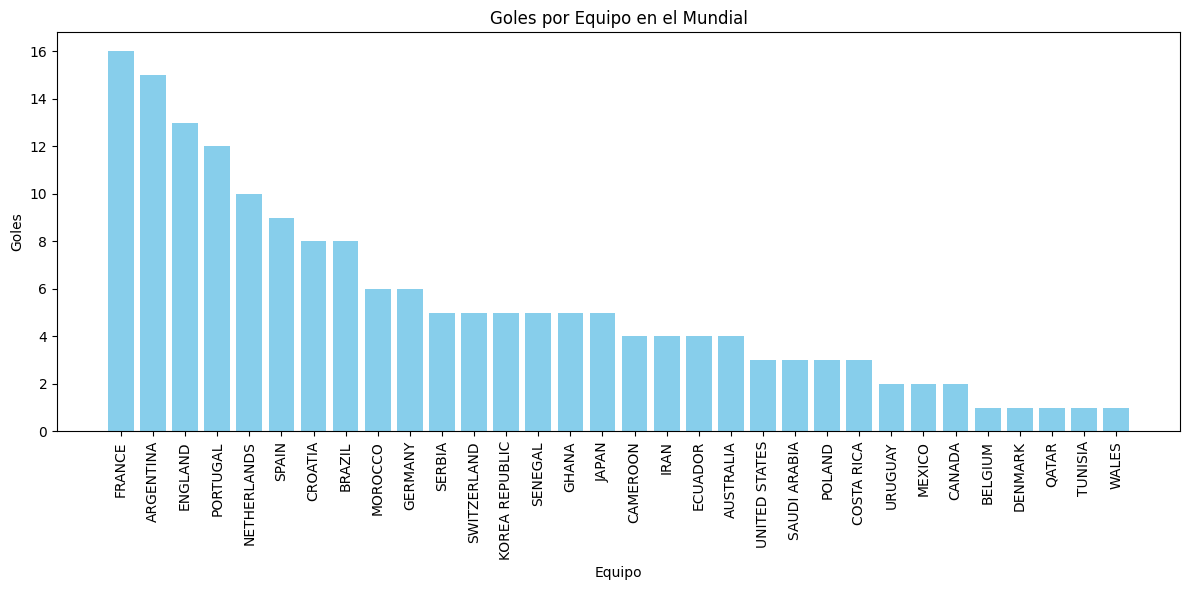

In [41]:
# Graficar los goles por equipo en todo el mundial
fig, ax = plt.subplots(figsize=(12, 6))
goles_home = mundial.groupby('1')['1_goals'].sum()
goles_away = mundial.groupby('2')['2_goals'].sum()
goles_equipo = goles_home.add(goles_away, fill_value=0).sort_values(ascending=False)

count = goles_equipo.values
bar_labels = goles_equipo.index
ax.bar(bar_labels, count, color='skyblue')
ax.set_xlabel('Equipo')
ax.set_ylabel('Goles')
ax.set_title('Goles por Equipo en el Mundial')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [44]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar
goles_equipo.idxmax()

'FRANCE'

In [49]:
# Por cada partido, cual fue la diferencia de goles?
# Completar
diferenciaGoles = (mundial['1_goals'] - mundial['2_goals'])
mundial['diferenciaGoles'] = diferenciaGoles
diferenciaGoles, mundial['1'],mundial['2']

(0    -2
 1     4
 2    -2
 3     0
 4    -1
      ..
 59   -1
 60    3
 61    2
 62    1
 63    0
 Length: 64, dtype: int64,
 0             QATAR
 1           ENGLAND
 2           SENEGAL
 3     UNITED STATES
 4         ARGENTINA
           ...      
 59          ENGLAND
 60        ARGENTINA
 61           FRANCE
 62          CROATIA
 63        ARGENTINA
 Name: 1, Length: 64, dtype: object,
 0          ECUADOR
 1             IRAN
 2      NETHERLANDS
 3            WALES
 4     SAUDI ARABIA
           ...     
 59          FRANCE
 60         CROATIA
 61         MOROCCO
 62         MOROCCO
 63          FRANCE
 Name: 2, Length: 64, dtype: object)

In [52]:
# Por cada partido, cual fue el equipo que gano?
# Completar
def Ganador(row):
    if row['1_goals'] > row['2_goals']:
        return row['1']
    elif row['2_goals'] > row['1_goals']:
        return row['2']
    else:
        return 'Empate'

mundial['Ganador'] = mundial.apply(Ganador, axis=1)
mundial[['1', '2', '1_goals', '2_goals', 'Ganador']]

,1,2,1_goals,2_goals,Ganador
0,QATAR,ECUADOR,0,2,ECUADOR
1,ENGLAND,IRAN,6,2,ENGLAND
2,SENEGAL,NETHERLANDS,0,2,NETHERLANDS
3,UNITED STATES,WALES,1,1,Empate
4,ARGENTINA,SAUDI ARABIA,1,2,SAUDI ARABIA
...,...,...,...,...,...
59,ENGLAND,FRANCE,1,2,FRANCE
60,ARGENTINA,CROATIA,3,0,ARGENTINA
61,FRANCE,MOROCCO,2,0,FRANCE
62,CROATIA,MOROCCO,2,1,CROATIA


In [58]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# Completar
for fase in mundial['group'].unique():
    partidos_fase = mundial[mundial['group'] == fase]
    equipos_fase = pd.concat([partidos_fase['1'], partidos_fase['2']]).unique()

    goles_fase = {}
    for eq in equipos_fase:
        como_local = partidos_fase[partidos_fase['1'] == eq]['1_goals'].sum()
        como_visitante = partidos_fase[partidos_fase['2'] == eq]['2_goals'].sum()
        goles_fase[eq] = como_local + como_visitante

    mejor = max(goles_fase, key=goles_fase.get)
    print(f"{fase}: {mejor} ({goles_fase[mejor]} goles)")


Group A: SENEGAL (5 goles)
Group B: ENGLAND (9 goles)
Group C: ARGENTINA (5 goles)
Group D: FRANCE (6 goles)
Group F: MOROCCO (4 goles)
Group E: SPAIN (9 goles)
Group G: SERBIA (5 goles)
Group H: PORTUGAL (6 goles)
Round of 16: PORTUGAL (6 goles)
Quarter-final: NETHERLANDS (2 goles)
Semi-Final: ARGENTINA (3 goles)
Play-off for third place: CROATIA (2 goles)
Final: ARGENTINA (3 goles)


### Tercera Parte

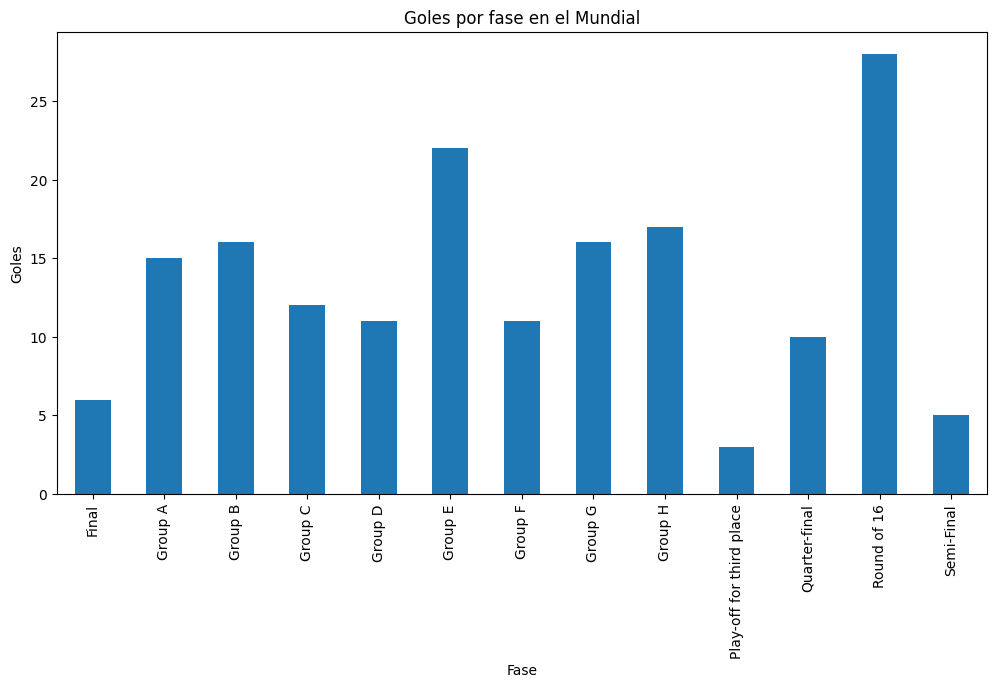

In [61]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar
# Goles totales por etapa
fig, ax = plt.subplots(figsize=(12, 6))
goles_por_fase = mundial.groupby('group')['1_goals'].sum()+ mundial.groupby('group')['2_goals'].sum()


goles_por_fase.plot(kind='bar', figsize=(12,6))
plt.xlabel('Fase')
plt.ylabel('Goles')
plt.title('Goles por fase en el Mundial')
plt.show()
